# Q1. Explain the basic concept of clustering and give examples of applications where clustering is useful.

Clustering is a method used in machine learning to group similar data points together. It is an unsupervised algorithm, meaning that it doesn't require labeled data for training. The goal of clustering is to find hidden patterns or structures in data. One simple example is grouping similar types of fruits together based on their features like color, size, and texture. Clustering is useful in various applications, such as:

   - Market segmentation
   - Social network analysis
   - Search result grouping
   - Medical imaging
   - Image segmentation
   - Anomaly detection

# Q2. What is DBSCAN and how does it differ from other clustering algorithms such as k-means and hierarchical clustering?

DBSCAN, which stands for Density-Based Spatial Clustering of Applications with Noise, is a clustering algorithm that groups data points based on their density. Unlike k-means, which requires specifying the number of clusters in advance, DBSCAN does not need this information. It is also able to handle clusters of different shapes and sizes, and it efficiently handles outliers and noisy datasets. DBSCAN identifies clusters by checking the density of each point's neighborhood, and it does not force every point into a cluster, allowing for the identification of noise points. This makes it particularly useful for data with irregular shapes and when the number of clusters is not known beforehand

# Q3. How do you determine the optimal values for the epsilon and minimum points parameters in DBSCAN clustering?

Determining the optimal values for the epsilon (ε) and minimum points (MinPts) parameters in DBSCAN clustering can be done using the following methods:
   - K-distance plot: Calculate the distance to the k-nearest neighbors for each point, sort the points based on this distance, and look for a knee point in the k-distance curve. The optimal epsilon value is usually around the distance of this knee point1
   - Range-based approach: Choose a range for the epsilon value based on the data's characteristics and the desired cluster resolution. For example, one common heuristic is to use ϵ=ln(n)nϵ=nln(n)​, where n is the total number of points to be clustered5   
   - Using a library or package: Some libraries, like the R package fpc, provide functions to help estimate the optimal epsilon value. You can use these functions to compute the appropriate epsilon value for your dataset4
    
Remember that the choice of epsilon and minimum points values can significantly impact the clustering results. It's essential to experiment with different values and visualize the clusters to ensure the best parameter settings

# Q4. How does DBSCAN clustering handle outliers in a dataset?

DBSCAN clustering handles outliers in a dataset by considering them as noise points that do not belong to any cluster. It works by identifying clusters based on their density, and data points that are too far from the centroid of their cluster or have a low density can be marked as outliers or noise

# Q5. How does DBSCAN clustering differ from k-means clustering?

- DBSCAN: Density-based, finds arbitrary shapes, no need for predefining cluster count. Good with outliers and varying densities.
- k-means: Centroid-based, assumes spherical clusters, needs predefining cluster count. Sensitive to outliers and varying densities.

# Q6. Can DBSCAN clustering be applied to datasets with high dimensional feature spaces? If so, what are some potential challenges?

Yes, applicable, but challenges exist:
   -  Curse of dimensionality: distances become meaningless, affecting density calculations.
   - Parameter tuning: Epsilon and MinPts become crucial for good results.

# Q7. How does DBSCAN clustering handle clusters with varying densities?

- Handles them well! Identifies clusters based on local density, not global. Different densities form separate clusters.

# Q8. What are some common evaluation metrics used to assess the quality of DBSCAN clustering results?

- Silhouette coefficient: measures cluster cohesion and separation.
- Davies-Bouldin index: compares within-cluster distances to between-cluster distances.
- Calinski-Harabasz index: ratio of inter-cluster variance to intra-cluster variance.

# Q9. Can DBSCAN clustering be used for semi-supervised learning tasks?

Limitedly. Can leverage labeled data to guide density calculations, but not directly for classification tasks.

# Q10. How does DBSCAN clustering handle datasets with noise or missing values?

- Sensitive to noise. Outliers can be misclassified as clusters.
- Missing values can affect density calculations, requiring proper imputation techniques.

# Q11. Implement the DBSCAN algorithm using a python programming language, and apply it to a sample dataset. Discuss the clustering results and interpret the meaning of the obtained clusters.

In [18]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
%matplotlib inline

In [19]:
X , y = make_moons(n_samples=250 , noise=0.10)

In [20]:
X

array([[ 1.13206283, -0.41284989],
       [ 0.51489951, -0.35883474],
       [ 0.43413714,  0.95649561],
       [ 0.62551149,  0.87686722],
       [ 1.82040549, -0.38194962],
       [ 1.47213378, -0.27848519],
       [-0.67679789,  0.44014479],
       [-0.17396887,  1.0038596 ],
       [-0.0597269 ,  0.42973568],
       [ 0.77381453, -0.38782859],
       [ 1.2373536 , -0.44039713],
       [-0.92792182,  0.31744903],
       [ 1.26964431, -0.38425582],
       [ 1.05450417, -0.52795828],
       [-0.90466383,  0.40200418],
       [ 1.09098139,  0.19604812],
       [ 1.05251615, -0.38543664],
       [ 0.29607423,  1.1034797 ],
       [ 0.66991964, -0.56319337],
       [ 1.9178457 ,  0.36813842],
       [ 0.8208092 ,  0.1917799 ],
       [ 0.19584165,  0.86090628],
       [ 0.99534886, -0.53829559],
       [ 1.97709896,  0.55335959],
       [-0.64824277,  0.74102231],
       [-0.49216299,  0.70098556],
       [ 1.9095714 ,  0.29897208],
       [ 0.55703534,  0.83370127],
       [ 0.28578383,

In [21]:
y

array([1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1], dtype=int64)

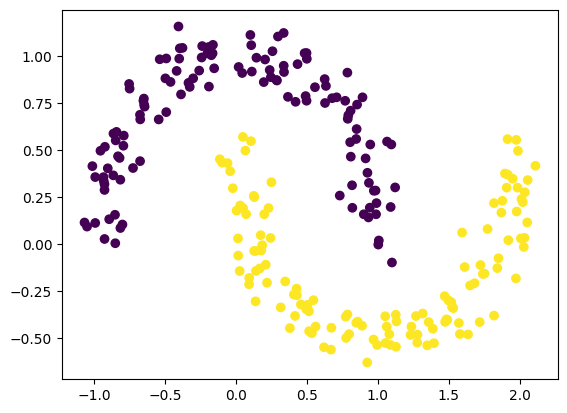

In [22]:
plt.scatter(X[:,0],X[:,1],c=y)

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [24]:
X_scaled = scaler.fit_transform(X)

In [25]:
X_scaled

array([[ 7.21142571e-01, -1.32522875e+00],
       [ 1.13832541e-02, -1.21819925e+00],
       [-8.14962892e-02,  1.38809076e+00],
       [ 1.38590888e-01,  1.23030933e+00],
       [ 1.51276063e+00, -1.26400073e+00],
       [ 1.11223602e+00, -1.05898889e+00],
       [-1.35911028e+00,  3.64956151e-01],
       [-7.80839397e-01,  1.48194116e+00],
       [-6.49457151e-01,  3.44330807e-01],
       [ 3.09144546e-01, -1.27564975e+00],
       [ 8.42230625e-01, -1.37981283e+00],
       [-1.64791156e+00,  1.21837966e-01],
       [ 8.79366069e-01, -1.26857041e+00],
       [ 6.31947416e-01, -1.55331277e+00],
       [-1.62116406e+00,  2.89381622e-01],
       [ 6.73897483e-01, -1.18714503e-01],
       [ 6.29661123e-01, -1.27091016e+00],
       [-2.40273446e-01,  1.67933558e+00],
       [ 1.89661807e-01, -1.62313012e+00],
       [ 1.62482026e+00,  2.22277570e-01],
       [ 3.63190055e-01, -1.27171876e-01],
       [-3.55544411e-01,  1.19868318e+00],
       [ 5.63916742e-01, -1.57379587e+00],
       [ 1.

In [26]:
dbscan = DBSCAN(eps = 0.5)

In [27]:
dbscan.fit(X_scaled)

DBSCAN()

In [28]:
dbscan.labels_

array([0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 0], dtype=int64)

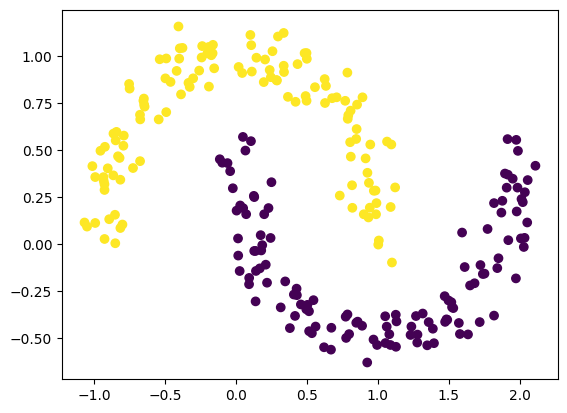

In [29]:
plt.scatter(X[:,0],X[:,1],c=dbscan.labels_)